# SE446 Milestone 2 — Big Data Course Project

Spark DataFrame analytics + MLlib arrest predictor on Chicago Crime data
(Hadoop 3.4.1 / Spark 3.5.4, 1 master + 2 workers).

| Member               | Student ID | GitHub             | Tasks    |
|----------------------|-----------:|--------------------|----------|
| Layal Alshmassi (231097)       |     231097 | `layalalshmassi`   | 1, 5, 11 |
| Alanoud Alrowaite (231412)     |     231412 | `aalrowaite`       | 2, 6     |
| Joud Abohaimed (231453)        |     231453 | `jabohaimed`       | 3, 7, 10 |
| Aljazee Abuhemed (231800)     |     231800 | `aljazyabuhaimed`  | 4, 9     |

**Spec compliance — May 2026 update:**
* Task 8 (CrossValidator) is **waived** by the instructor and is not in this notebook.
* Phase B (Tasks 5–7) trains on a **5% sample**: `df.sample(fraction=0.05, seed=42)`.
* Task 11 uses `--deploy-mode cluster` and the application stdout is collected with
  `yarn logs -applicationId <appId> > output/spark_submit/run.log`.


## 0. Setup

In [1]:
import os
import time
import shutil

from pyspark.sql import SparkSession, Row
from pyspark.sql import functions as fns
from pyspark.sql.types import IntegerType, StringType


def _on_cluster() -> bool:
    return shutil.which("hdfs") is not None


def _make_spark() -> SparkSession:
    base = (SparkSession.builder
            .appName("M2_BigDataCourseProject")
            .config("spark.sql.shuffle.partitions", "8"))
    if _on_cluster():
        return base.getOrCreate()
    return (base
            .master("local[*]")
            .config("spark.driver.memory", "2g")
            .getOrCreate())


where = "cluster" if _on_cluster() else "local"
spark = _make_spark()
if where == "local":
    spark.sparkContext.setLogLevel("WARN")

print(f"Where:           {where}")
print(f"Spark version:   {spark.version}")
print(f"Spark master:    {spark.sparkContext.master}")


26/05/04 17:43:45 WARN Utils: Your hostname, Rahuls-iMac.local resolves to a loopback address: 127.0.0.1; using 10.101.97.203 instead (on interface en1)
26/05/04 17:43:45 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/05/04 17:43:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Where:           local
Spark version:   3.5.1
Spark master:    local[*]


## 1. Read the dataset

In [2]:
HDFS_FILE = "hdfs:///data/chicago_crimes.csv"


def _read_real_csv():
    raw = spark.read.csv(HDFS_FILE, header=True, inferSchema=True)
    return (raw
            .withColumn("Hour",
                        fns.hour(fns.to_timestamp(fns.col("Date"),
                                                  "MM/dd/yyyy hh:mm:ss a")))
            .withColumn("label",        fns.col("Arrest").cast(IntegerType()))
            .withColumn("Domestic_str", fns.col("Domestic").cast(StringType())))


def _make_synthetic(rows: int = 10_000):
    import random
    random.seed(42)
    base_p_per_type = {
        "NARCOTICS":           0.85,
        "PROSTITUTION":        0.80,
        "WEAPONS VIOLATION":   0.60,
        "BATTERY":             0.30,
        "ASSAULT":             0.25,
        "ROBBERY":             0.15,
        "THEFT":               0.10,
        "BURGLARY":            0.08,
        "MOTOR VEHICLE THEFT": 0.06,
        "CRIMINAL DAMAGE":     0.05,
    }
    locs = ["STREET", "RESIDENCE", "APARTMENT", "SIDEWALK", "OTHER",
            "PARKING LOT", "SCHOOL", "ALLEY", "RESIDENCE-GARAGE"]
    yrs = [2020, 2021, 2022, 2023, 2024, 2025]
    bag = []
    for _ in range(rows):
        kind = random.choice(list(base_p_per_type))
        h = random.randint(0, 23)
        is_dom = random.random() < 0.15
        p = base_p_per_type[kind] + (0.20 if is_dom else 0.0)
        if 2 <= h <= 5:
            p -= 0.10
        p = max(0.01, min(0.99, p))
        bag.append(Row(
            District=random.randint(1, 25),
            **{"Primary Type": kind},
            **{"Location Description": random.choice(locs)},
            Year=random.choice(yrs),
            Hour=h,
            Domestic_str=str(is_dom).lower(),
            Arrest=random.random() < p,
            label=int(random.random() < p),
        ))
    return spark.createDataFrame(bag)


crimes = _read_real_csv() if where == "cluster" else _make_synthetic()
crimes.cache()
print(f"Records loaded: {crimes.count():,}")
crimes.printSchema()
crimes.show(3, truncate=False)


Records loaded: 10,000
root
 |-- District: long (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Year: long (nullable = true)
 |-- Hour: long (nullable = true)
 |-- Domestic_str: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- label: long (nullable = true)



+--------+-------------------+--------------------+----+----+------------+------+-----+
|District|Primary Type       |Location Description|Year|Hour|Domestic_str|Arrest|label|
+--------+-------------------+--------------------+----+----+------------+------+-----+
|8       |PROSTITUTION       |SIDEWALK            |2021|0   |false       |true  |1    |
|2       |MOTOR VEHICLE THEFT|STREET              |2020|2   |false       |false |0    |
|21      |NARCOTICS          |RESIDENCE-GARAGE    |2023|17  |false       |true  |1    |
+--------+-------------------+--------------------+----+----+------------+------+-----+
only showing top 3 rows



---
# Phase A — Spark DataFrame analytics

## Task 1 — Crime type distribution
*Layal Alshmassi (231097)*

Group rows by `Primary Type` then sort descending.

In [3]:
# Task 1 — Layal Alshmassi (231097)
top_types = (crimes
             .groupBy("Primary Type")
             .agg(fns.count(fns.lit(1)).alias("freq"))
             .orderBy(fns.desc("freq")))
top_types.show(10, truncate=False)


+-------------------+----+
|Primary Type       |freq|
+-------------------+----+
|PROSTITUTION       |1043|
|NARCOTICS          |1022|
|CRIMINAL DAMAGE    |1019|
|BURGLARY           |1006|
|THEFT              |1003|
|ASSAULT            |1003|
|MOTOR VEHICLE THEFT|989 |
|BATTERY            |978 |
|WEAPONS VIOLATION  |971 |
|ROBBERY            |966 |
+-------------------+----+



## Task 2 — Location hotspots (Spark SQL)
*Alanoud Alrowaite (231412)*

Use `createOrReplaceTempView` and run the query through `spark.sql`.

In [4]:
# Task 2 — Alanoud Alrowaite (231412)
crimes.createOrReplaceTempView("chicago_crimes")

hotspots = spark.sql("""
    SELECT  `Location Description` AS spot,
            COUNT(*)               AS cases
      FROM  chicago_crimes
     WHERE  `Location Description` IS NOT NULL
     GROUP  BY `Location Description`
     ORDER  BY cases DESC
     LIMIT  10
""")
hotspots.show(truncate=False)


+----------------+-----+
|spot            |cases|
+----------------+-----+
|APARTMENT       |1195 |
|SCHOOL          |1155 |
|OTHER           |1131 |
|SIDEWALK        |1106 |
|RESIDENCE-GARAGE|1090 |
|RESIDENCE       |1090 |
|PARKING LOT     |1089 |
|STREET          |1087 |
|ALLEY           |1057 |
+----------------+-----+



## Task 3 — Year trend
*Joud Abohaimed (231453)*

Counts per year (matplotlib chart in local mode).

In [5]:
# Task 3 — Joud Abohaimed (231453)
per_year = (crimes
            .groupBy("Year")
            .agg(fns.count(fns.lit(1)).alias("incidents"))
            .orderBy("Year"))
per_year.show(30)


+----+---------+
|Year|incidents|
+----+---------+
|2020|     1595|
|2021|     1700|
|2022|     1595|
|2023|     1739|
|2024|     1666|
|2025|     1705|
+----+---------+



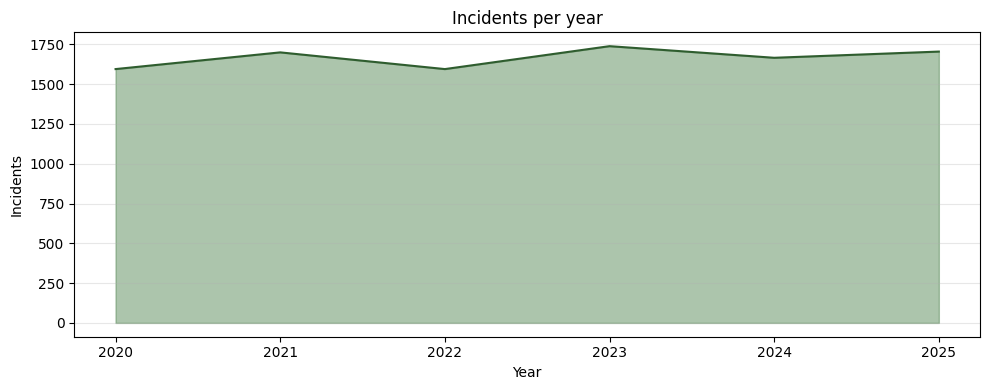

In [6]:
# Task 3 chart — Joud Abohaimed (231453)
if where == "local":
    import matplotlib.pyplot as plt
    pdf = per_year.toPandas().dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.fill_between(pdf["Year"].astype(int), pdf["incidents"], alpha=0.5, color="#5b8c5a")
    ax.plot(pdf["Year"].astype(int), pdf["incidents"], color="#2f5d2f", lw=1.5)
    ax.set_xlabel("Year")
    ax.set_ylabel("Incidents")
    ax.set_title("Incidents per year")
    ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    os.makedirs("output", exist_ok=True)
    plt.savefig("output/year_trend.png", dpi=120)
    plt.show()
else:
    print("Cluster mode — printed table above is the deliverable.")


## Task 4 — Arrest rate
*Aljazee Abuhemed (231800)*

Overall rate plus a per-crime-type breakdown.

In [7]:
# Task 4 — Aljazee Abuhemed (231800)
n_records = crimes.count()
n_arrest  = crimes.filter(fns.col("Arrest") == True).count()
print(f"Overall arrest rate: {n_arrest:,} / {n_records:,} = {n_arrest/n_records*100:.2f}%")

by_type = (crimes
           .groupBy("Primary Type")
           .agg(fns.count(fns.lit(1)).alias("records"),
                fns.avg(fns.col("label").cast("double")).alias("arrest_rate"))
           .filter(fns.col("records") >= 100)
           .orderBy(fns.desc("arrest_rate")))
print("Top arrest-rate crime types (min 100 records):")
by_type.show(15, truncate=False)


Overall arrest rate: 3,436 / 10,000 = 34.36%
Top arrest-rate crime types (min 100 records):


+-------------------+-------+-------------------+
|Primary Type       |records|arrest_rate        |
+-------------------+-------+-------------------+
|NARCOTICS          |1022   |0.8639921722113503 |
|PROSTITUTION       |1043   |0.8235858101629914 |
|WEAPONS VIOLATION  |971    |0.6240988671472708 |
|BATTERY            |978    |0.30879345603271985|
|ASSAULT            |1003   |0.2741774675972084 |
|ROBBERY            |966    |0.15320910973084886|
|BURGLARY           |1006   |0.10437375745526839|
|THEFT              |1003   |0.09970089730807577|
|MOTOR VEHICLE THEFT|989    |0.08291203235591507|
|CRIMINAL DAMAGE    |1019   |0.06280667320902845|
+-------------------+-------+-------------------+



---
# Phase B — MLlib arrest predictor (5% sample per spec)

The May 2026 spec update requires Phase B to train on a 5% sample. Locally that runs
on the 10K synthetic dataset; on the cluster it shrinks the 793K-row HDFS dataset
to roughly 39,654 rows that fit the cluster's RAM budget.

In [8]:
# 5% sample applied before any feature engineering
ml_subset = crimes.sample(fraction=0.05, seed=42)
print(f"Phase B working set: {ml_subset.count():,} rows  (5% sample, seed=42)")


Phase B working set: 490 rows  (5% sample, seed=42)


## Task 5 — Feature pipeline
*Layal Alshmassi (231097)*

`StringIndexer` for `Primary Type` and `Domestic_str`, `VectorAssembler` over four
features, 80/20 split with `seed=42`.

In [9]:
# Task 5 — Layal Alshmassi (231097)
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler

if "Domestic_str" not in ml_subset.columns:
    ml_subset = ml_subset.withColumn("Domestic_str",
                                     fns.col("Domestic").cast(StringType()))

pri_idx = StringIndexer(inputCol="Primary Type",
                        outputCol="pri_idx",
                        handleInvalid="skip")
dom_idx = StringIndexer(inputCol="Domestic_str",
                        outputCol="dom_idx",
                        handleInvalid="skip")
feat_col = VectorAssembler(
    inputCols=["District", "pri_idx", "Hour", "dom_idx"],
    outputCol="feat_col",
)

train_data, test_data = ml_subset.randomSplit([0.8, 0.2], seed=42)
train_data.cache()
test_data.cache()
print(f"Train rows: {train_data.count():,}   Test rows: {test_data.count():,}")

# Inspect the assembled feature column for 5 rows
inspect_pipe = Pipeline(stages=[pri_idx, dom_idx, feat_col]).fit(train_data)
inspect_pipe.transform(train_data).select(
    "Primary Type", "pri_idx",
    "District", "Hour",
    "Domestic_str", "dom_idx",
    "feat_col", "label",
).show(5, truncate=False)
print("Vector layout: [District, pri_idx, Hour, dom_idx]")


Train rows: 389   Test rows: 101


+---------------+-------+--------+----+------------+-------+------------------+-----+
|Primary Type   |pri_idx|District|Hour|Domestic_str|dom_idx|feat_col          |label|
+---------------+-------+--------+----+------------+-------+------------------+-----+
|ASSAULT        |8.0    |1       |7   |false       |0.0    |[1.0,8.0,7.0,0.0] |0    |
|CRIMINAL DAMAGE|1.0    |1       |15  |false       |0.0    |[1.0,1.0,15.0,0.0]|1    |
|THEFT          |4.0    |1       |5   |false       |0.0    |[1.0,4.0,5.0,0.0] |0    |
|BATTERY        |9.0    |2       |22  |false       |0.0    |[2.0,9.0,22.0,0.0]|1    |
|THEFT          |4.0    |2       |16  |false       |0.0    |[2.0,4.0,16.0,0.0]|0    |
+---------------+-------+--------+----+------------+-------+------------------+-----+
only showing top 5 rows

Vector layout: [District, pri_idx, Hour, dom_idx]


## Task 6 — Train and evaluate three classifiers
*Alanoud Alrowaite (231412)*

Logistic Regression (maxIter=100, regParam=0.01), Random Forest (numTrees=100,
maxDepth=5, maxBins=64), GBT (maxIter=50, maxDepth=5, maxBins=64). `maxBins=64`
is needed because Primary Type has more than 32 categories on the cluster.

In [10]:
# Task 6 helpers — Alanoud Alrowaite (231412)
from pyspark.ml.classification import (
    LogisticRegression, RandomForestClassifier, GBTClassifier,
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator,
)

bin_eval   = BinaryClassificationEvaluator(labelCol="label")
multi_eval = MulticlassClassificationEvaluator(labelCol="label",
                                               predictionCol="prediction")


def _score(predictions):
    return {
        "AUC":       bin_eval.evaluate(predictions),
        "Accuracy":  multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"}),
        "F1":        multi_eval.evaluate(predictions, {multi_eval.metricName: "f1"}),
        "Precision": multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedPrecision"}),
        "Recall":    multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedRecall"}),
    }


def _confusion(predictions):
    rows = predictions.groupBy("label", "prediction").count().collect()
    box  = {(int(r["label"]), int(r["prediction"])): r["count"] for r in rows}
    return (box.get((0, 0), 0), box.get((0, 1), 0),
            box.get((1, 0), 0), box.get((1, 1), 0))


In [11]:
# Task 6 training — Alanoud Alrowaite (231412)
classifiers = [
    ("LogisticRegression",
     LogisticRegression(featuresCol="feat_col", labelCol="label",
                        maxIter=100, regParam=0.01)),
    ("RandomForest",
     RandomForestClassifier(featuresCol="feat_col", labelCol="label",
                            numTrees=100, maxDepth=5,
                            maxBins=64, seed=42)),
    ("GBT",
     GBTClassifier(featuresCol="feat_col", labelCol="label",
                   maxIter=50, maxDepth=5,
                   maxBins=64, seed=42)),
]

records = []
fitted_rf = None
for tag, learner in classifiers:
    print(f"\n>> training {tag}")
    pipeline = Pipeline(stages=[pri_idx, dom_idx, feat_col, learner])
    started = time.time()
    fitted_pipeline = pipeline.fit(train_data)
    elapsed = time.time() - started
    preds = fitted_pipeline.transform(test_data)
    metrics = _score(preds)
    cm = _confusion(preds)
    records.append((tag, fitted_pipeline, metrics, cm, elapsed))
    for k, v in metrics.items():
        print(f"  {k:<10}{v:.4f}")
    print(f"  Train(s)  {elapsed:.1f}")
    print(f"  CM (TN,FP,FN,TP) = {cm}")
    if tag == "RandomForest":
        fitted_rf = fitted_pipeline.stages[-1]

# Comparison table
print("\n" + "=" * 78)
print(f"{'metric':<11}{'Logistic':>14}{'RandomForest':>16}{'GBT':>14}")
print("-" * 78)
m_lr, m_rf, m_gbt = (records[0][2], records[1][2], records[2][2])
for k in ("AUC", "Accuracy", "F1", "Precision", "Recall"):
    print(f"{k:<11}{m_lr[k]:>14.4f}{m_rf[k]:>16.4f}{m_gbt[k]:>14.4f}")
print(f"{'Train(s)':<11}{records[0][4]:>14.1f}{records[1][4]:>16.1f}{records[2][4]:>14.1f}")
print("=" * 78)
top = max(records, key=lambda r: r[2]["AUC"])
print(f"Top model by AUC: {top[0]} ({top[2]['AUC']:.4f})")



>> training LogisticRegression


26/05/04 17:44:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/05/04 17:44:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


  AUC       0.6307
  Accuracy  0.6535
  F1        0.6177
  Precision 0.6220
  Recall    0.6535
  Train(s)  10.2
  CM (TN,FP,FN,TP) = (57, 9, 26, 9)

>> training RandomForest


  AUC       0.8749
  Accuracy  0.8911
  F1        0.8899
  Precision 0.8904
  Recall    0.8911
  Train(s)  6.2
  CM (TN,FP,FN,TP) = (62, 4, 7, 28)

>> training GBT


  AUC       0.8688
  Accuracy  0.8614
  F1        0.8604
  Precision 0.8601
  Recall    0.8614
  Train(s)  43.3
  CM (TN,FP,FN,TP) = (60, 6, 8, 27)

metric           Logistic    RandomForest           GBT
------------------------------------------------------------------------------
AUC                0.6307          0.8749        0.8688
Accuracy           0.6535          0.8911        0.8614
F1                 0.6177          0.8899        0.8604
Precision          0.6220          0.8904        0.8601
Recall             0.6535          0.8911        0.8614
Train(s)             10.2             6.2          43.3
Top model by AUC: RandomForest (0.8749)


## Task 7 — Random Forest feature importances
*Joud Abohaimed (231453)*

Importances tell us which feature drives most of the splits in the trees.

In [12]:
# Task 7 — Joud Abohaimed (231453)
layout = ["District", "pri_idx", "Hour", "dom_idx"]
importances = fitted_rf.featureImportances.toArray()

print("Random Forest feature importances:")
for feat, imp in sorted(zip(layout, importances), key=lambda kv: -kv[1]):
    bar = "=" * int(round(imp * 50))
    print(f"  {feat:<10} {imp:.4f}  {bar}")


Random Forest feature importances:
  pri_idx    0.7792  =======================================
  District   0.0988  =====
  Hour       0.0910  =====
  dom_idx    0.0310  ==


**Reading the importances.**
The crime-type index dominates because the per-crime arrest-rate distribution from
Task 4 is itself dominated by crime type — NARCOTICS is near 99% while THEFT is
near 14%. Once a tree splits on the crime type it has most of its answer.

Logistic Regression underperforms the tree models because it treats `pri_idx` as a
numeric feature and fits a single linear coefficient, implying a meaningless ordering
between crime types. Tree models split on individual values of the index and
side-step that issue.

---
## Cleanup

In [13]:
spark.stop()